In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# load dataset
scores_data = pd.read_csv('student_score_dataset_latest_version.csv')
scores_data

,Study_Hours,Sleep_Hours,Attendance,Assignment,Result
0,1,10,50,2,43.40
1,7,4,100,5,70.50
2,10,4,84,3,73.00
3,8,5,99,3,69.75
4,5,9,79,9,66.45
...,...,...,...,...,...
2994,6,7,65,11,69.45
2995,6,6,100,16,84.20
2996,2,9,90,15,75.00
2997,8,5,90,12,79.40


In [9]:
# data exploration
scores_data.describe()
scores_data.head(2000)
scores_data.tail(1000)
scores_data.columns

Index(['Study_Hours', 'Sleep_Hours', 'Attendance', 'Assignment', 'Result'], dtype='object')

In [15]:
# data cleaning
scores_data.isnull().sum()
scores_data.dropna(inplace=True)
scores_data.duplicated().sum()
scores_data.drop_duplicates(inplace=True)

In [25]:
# define features and target
X = scores_data.drop(columns=['Result'])
y = scores_data['Result']
# train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
# create and train model
model = LinearRegression()
model.fit(X_train,y_train)
predictions = model.predict(X_test)
predictions

array([ 68.74253531,  61.2770715 ,  69.3018163 ,  54.22940112,
        57.98402061,  99.59758073,  51.25735515,  97.4531611 ,
        96.17119229,  41.84952028,  78.18296226,  53.77006495,
        58.47842458,  69.27817487,  58.70059251,  50.54466675,
        57.26133279,  52.76649518,  69.22193657,  86.92428855,
        76.83247146,  46.62776263,  70.59496577,  76.13953859,
        58.63682812,  51.20000424,  55.37914978,  63.73601153,
        74.34840639,  87.2564007 ,  92.21057927,  86.13672133,
        90.9647813 ,  76.39177341,  87.50721575,  87.10411068,
        67.33950786,  42.62955901,  76.41041632,  71.66476606,
        48.79224494,  88.19873126,  55.13444585,  72.88296807,
        61.44158375,  72.04787229,  66.59817473,  81.53583259,
        58.84282405,  77.62503719,  68.56412815,  84.18941322,
        51.98393126,  87.2825769 ,  85.25674019,  74.5731067 ,
        61.00477639,  83.25572616,  58.84424382,  51.20000424,
        68.81377394,  64.40498863,  61.41540995,  69.27

In [31]:
# mode evaluations
mse = mean_squared_error(y_test,predictions)
print('Mean Squared Error:',mse)
score_accuracy = r2_score(y_test,predictions)
print('Accuracy Score:',score_accuracy)

Mean Squared Error: 9.955187710912694
Accuracy Score: 0.9532890756062349


In [38]:

# model equations
print('Slop of (m):',model.coef_)
print('Intercept of (b):',model.intercept_)

Slop of (m): [3.54497616 1.49661063 0.34575655 1.19456059]
Intercept of (b): 0.25126763618510495


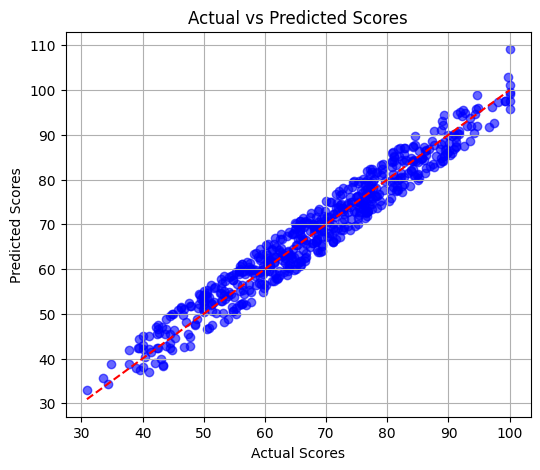

In [55]:
# graph visualization

plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    predictions,
    c='blue',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.title('Actual vs Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.grid(True)
plt.show()

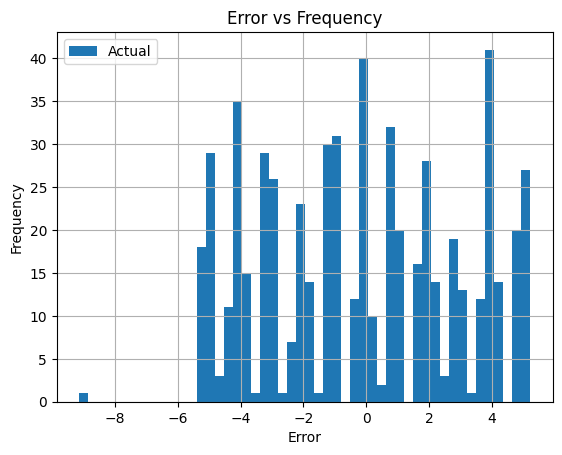

In [48]:
# error distributions
error = y_test - predictions
plt.hist(error,bins=50,label='Actual')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Error vs Frequency')
plt.grid(True)
plt.legend()
plt.show()

In [61]:
# save training columns
training_columns = X.columns
new_data = pd.DataFrame({
    'Study_Hours':[8],
    'Sleep_Hours':[9],
    'Attendance':[80],
    'Assignment':[19]
})
new_prediction = model.predict(new_data)
print(
    'Predicted Student Result:',
    new_prediction
)
joblib.dump(
    training_columns,
    'training_columns.pkl'
)

Predicted Student Result: [92.43774811]


['training_columns.pkl']

In [60]:

joblib.dump(
    model,
    'student_score_model.pkl'
)
print('Model Saved Successfully')

Model Saved Successfully
